# 02 · Fraud classification and validation

**Objective:** assess whether transaction amount and type can prioritise fraud reviews at payment initiation.

Logistic regression provides an interpretable baseline. A depth-limited decision tree captures non-linear
amount ranges and interactions with transaction type. Both models use fixed specifications.
Balance fields are excluded because the publisher warns that simulation cancellation behaviour affects them.

Training uses steps 1–323 and validation uses 324–377. Steps 378–743 were inspected in an earlier analysis
and are **not scored by the revised models**. Model selection, threshold selection and reported performance
share the validation period; these are development results, not an independent estimate of future performance.
The [original analysis](https://github.com/Lavicy/fraud-risk-monitoring/tree/c4519cb66e21e7f3aa88f990cfd301e423b0a276) remains available in Git history.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import average_precision_score, precision_recall_curve
from analysis_helpers import make_features, evaluate, threshold_comparison

TABLES, FIGURES, ARTIFACTS = Path('reports/tables'), Path('reports/figures'), Path('artifacts')
for folder in [TABLES, FIGURES, ARTIFACTS]:
    folder.mkdir(parents=True, exist_ok=True)
columns = ['step', 'type', 'amount', 'isFraud']
data = pd.read_csv('data/PS_20174392719_1491204439457_log.csv',
                   usecols=columns, dtype={'type': 'category'})
development = data.loc[data.type.isin(['TRANSFER', 'CASH_OUT']) & data.step.le(377)].copy()
del data  # Later rows are not used for model fitting, threshold choice or evaluation.

## 1. Temporal development split

Random splitting could mix earlier and later activity. Here we train on earlier steps and validate on later steps.
Both groups still belong to the same simulation and may contain related payments, so time ordering alone does not prove independence.

In [2]:
train = development.loc[development.step.le(323)].copy()
validation = development.loc[development.step.between(324, 377)].copy()
assert train.step.max() < validation.step.min()
assert train.index.intersection(validation.index).empty
assert len(train) + len(validation) == len(development)
split_summary = pd.DataFrame([
    {'period': name, 'first_step': int(frame.step.min()), 'last_step': int(frame.step.max()),
     'transactions': len(frame), 'fraud': int(frame.isFraud.sum()), 'fraud_rate': frame.isFraud.mean()}
    for name, frame in [('Training', train), ('Validation', validation)]
])
display(split_summary)
split_summary.to_csv(TABLES / 'model_windows.csv', index=False)

,period,first_step,last_step,transactions,fraud,fraud_rate
0,Training,1,323,1951895,3643,0.001866
1,Validation,324,377,410437,560,0.001364


## 2. Features available at transaction initiation

`log_amount = log(1 + amount)` reduces the effect of the long tail. `is_transfer` is 1 for TRANSFER and 0 for CASH_OUT.
No label, balance or account ID is passed to the feature function. The label is supplied separately as the outcome.

In [3]:
X_train = make_features(train[['amount', 'type']])
X_validation = make_features(validation[['amount', 'type']])
y_train, y_validation = train['isFraud'], validation['isFraud']
display(X_train.head())
assert list(X_train.columns) == ['log_amount', 'is_transfer']

,log_amount,is_transfer
2,5.204007,1
3,5.204007,0
15,12.342066,0
19,12.279840,1
24,12.649754,1


## 3. Model specifications

Logistic regression links the inputs to the log-odds of the outcome. A pipeline scales log amount using the
**training mean and standard deviation only**. The binary type indicator is passed through unchanged.
`class_weight='balanced'` gives the rare fraud class more influence in fitting; it does not create extra fraud records.
Weighted scores should not be interpreted as calibrated fraud probabilities.

The tree is limited to three decision levels, with at least 100 training rows in each leaf. These settings keep the
model constrained; they are fixed before this run and are not claimed to be optimal. The tree does not need scaling.

In [4]:
preprocessing = ColumnTransformer([
    ('amount', StandardScaler(), ['log_amount']),
], remainder='passthrough')
logistic = Pipeline([
    ('scale', preprocessing),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
])
tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=100,
                              class_weight='balanced', random_state=42)
models = {'Logistic regression': logistic, 'Small decision tree': tree}
scores = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    scores[name] = model.predict_proba(X_validation)[:, 1]
scaler = logistic.named_steps['scale'].named_transformers_['amount']
assert int(scaler.n_samples_seen_) == len(train)
assert np.isclose(scaler.mean_[0], X_train.log_amount.mean())
comparison = pd.DataFrame([
    {'model': name, 'validation_AP': average_precision_score(y_validation, values)}
    for name, values in scores.items()
])
display(comparison)
comparison.to_csv(TABLES / 'model_comparison.csv', index=False)

,model,validation_AP
0,Logistic regression,0.003317
1,Small decision tree,0.048637


## 4. Validation ranking performance

**Precision** is the fraction of alerts that are labelled fraud. **Recall** is the fraction of labelled fraud detected.
**F1** is their harmonic mean. **Average precision (AP)** summarises the precision–recall relationship across thresholds;
it is our PR-AUC summary, calculated using scikit-learn's non-interpolated definition.

Select the model with higher validation AP; an exact tie favours logistic regression because it appears first.
This selection uses the validation labels, so it does not produce an unbiased final performance estimate.

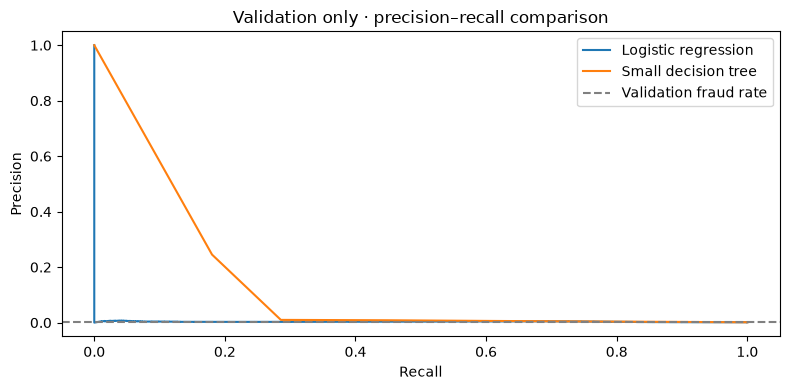

Selected model: Small decision tree


In [5]:
selected_name = comparison.loc[comparison.validation_AP.idxmax(), 'model']
selected_scores = scores[selected_name]
fig, ax = plt.subplots(figsize=(8, 4))
for name, values in scores.items():
    precision, recall, _ = precision_recall_curve(y_validation, values)
    ax.plot(recall, precision, label=name)
ax.axhline(y_validation.mean(), color='grey', linestyle='--', label='Validation fraud rate')
ax.set(xlabel='Recall', ylabel='Precision', title='Validation only · precision–recall comparison')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'validation_precision_recall.png', dpi=150)
plt.show()
print('Selected model:', selected_name)

## 5. Threshold selection

An alert is raised when `score >= threshold`. Compare the same small, predefined threshold list for the selected model.
Choose the largest F1; a tie favours the higher threshold. This is the best **among this list**, not an exhaustive optimum.
The validation period is used for both choices. F1 is the statistical selection criterion; it does not incorporate review costs or staffing constraints.

,threshold,precision,recall,F1,alerts,FP,FN
0,0.10,0.0014,1.0000,0.0027,410437,409877,0
1,0.20,0.0014,1.0000,0.0027,410437,409877,0
2,0.30,0.0043,0.7411,0.0086,96132,95717,145
3,0.40,0.0043,0.7411,0.0086,96132,95717,145
4,0.50,0.0047,0.7107,0.0094,84564,84166,162
5,0.60,0.0047,0.7107,0.0094,84564,84166,162
6,0.70,0.0081,0.4786,0.0159,33118,32850,292
7,0.80,0.0085,0.4482,0.0167,29435,29184,309
8,0.90,0.2451,0.1804,0.2078,412,311,459
9,0.95,0.2451,0.1804,0.2078,412,311,459


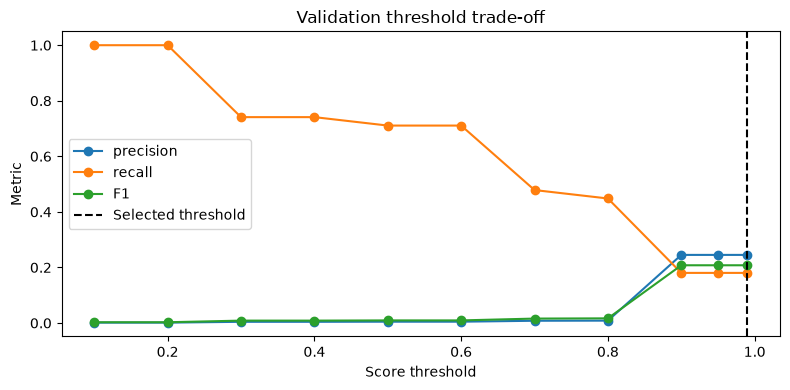

In [6]:
thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
threshold_table = threshold_comparison(y_validation, selected_scores, thresholds)
best = threshold_table.sort_values(['F1', 'threshold'], ascending=False).iloc[0]
threshold = float(best['threshold'])
result = evaluate(y_validation, selected_scores, threshold)
display(threshold_table[['threshold', 'precision', 'recall', 'F1', 'alerts', 'FP', 'FN']].round(4))
threshold_table.to_csv(TABLES / 'threshold_comparison.csv', index=False)
fig, ax = plt.subplots(figsize=(8, 4))
for metric in ['precision', 'recall', 'F1']:
    ax.plot(threshold_table.threshold, threshold_table[metric], marker='o', label=metric)
ax.axvline(threshold, color='black', linestyle='--', label='Selected threshold')
ax.set(xlabel='Score threshold', ylabel='Metric', title='Validation threshold trade-off')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'threshold_tradeoff.png', dpi=150)
plt.show()

## 6. Balance-feature sensitivity: historical evidence

The following two rows are **saved results from the earlier version**, using its fixed logistic specification and
the same train/validation windows. They are not new test results. Removing the balance information changed validation
AP from 1.0000 to about 0.0033. That shows strong dependence on those fields; it does not by itself prove why.
Because the publisher warns about the balances, they are excluded from the revised model.

The full feature specification is retained in the [original analysis](https://github.com/Lavicy/fraud-risk-monitoring/tree/c4519cb66e21e7f3aa88f990cfd301e423b0a276).
The original fixed model result is saved separately in `reports/reference/previous_test_result.csv`.

In [7]:
previous = pd.read_csv('reports/reference/previous_balance_check.csv')
display(previous[['feature_set', 'transactions', 'fraud_count', 'AP', 'F1']])
previous_amount_AP = previous.loc[previous.feature_set.eq('amount_and_type_only'), 'AP'].iloc[0]
# The same amount/type logistic baseline should reproduce its previous ranking result.
assert np.isclose(average_precision_score(y_validation, scores['Logistic regression']),
                  previous_amount_AP, atol=1e-6)

,feature_set,transactions,fraud_count,AP,F1
0,full,410437,560,1.000000,1.000000
1,amount_and_type_only,410437,560,0.003317,0.012343


## 7. Model interpretation

A positive logistic coefficient means a higher score when that input increases and the other input is held fixed.
The amount coefficient is per one training standard deviation of log amount; TRANSFER is compared with CASH_OUT.
These are associations in a weighted synthetic-data model, not causal effects.
In the tree plot, follow the condition at each node. The displayed class counts are weighted, not raw transaction counts.
The plotted class is the majority weighted class in a leaf; it is not the final alert decision at our selected threshold.

,feature,coefficient
0,Standardised log amount,0.375280
1,TRANSFER versus CASH_OUT,1.299455


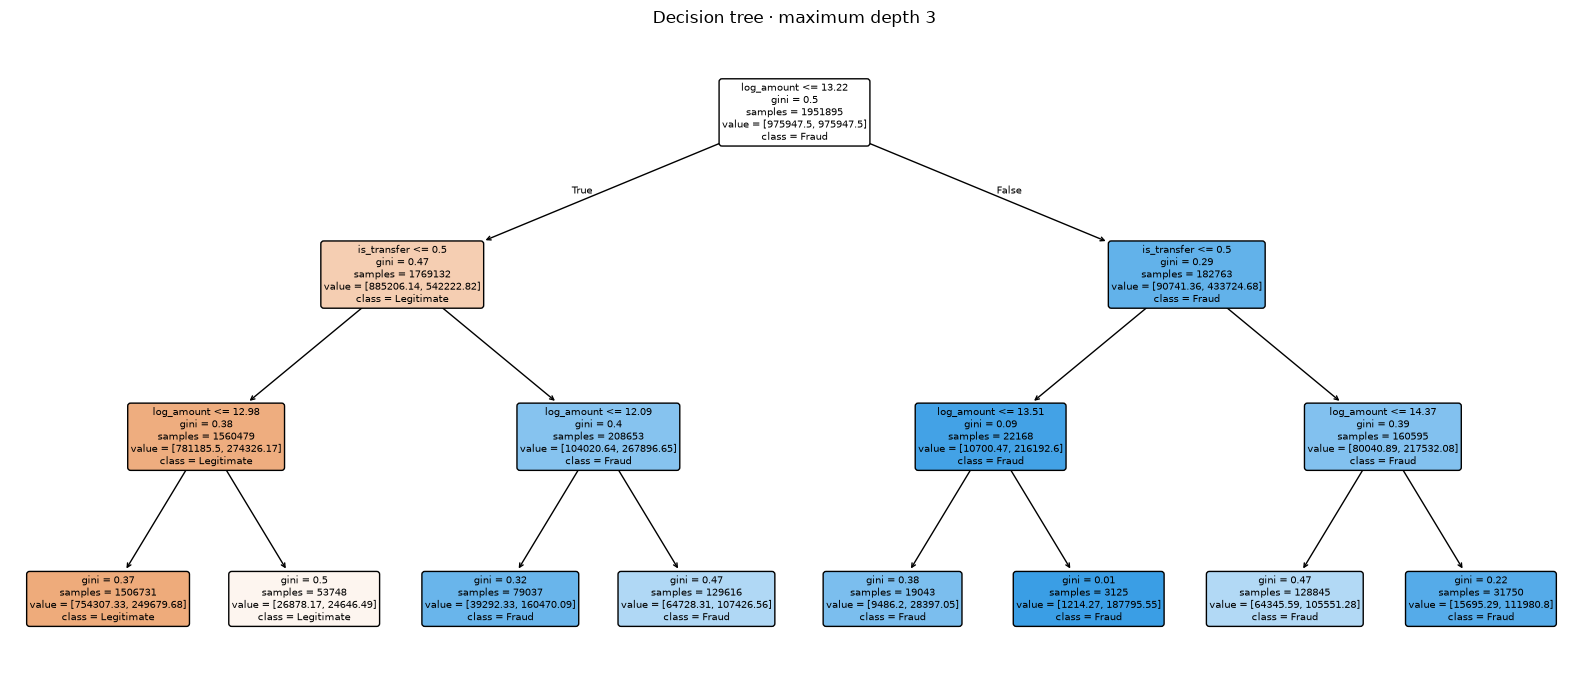

In [8]:
coefficients = pd.DataFrame({
    'feature': ['Standardised log amount', 'TRANSFER versus CASH_OUT'],
    'coefficient': logistic.named_steps['model'].coef_[0],
})
display(coefficients)
coefficients.to_csv(TABLES / 'logistic_coefficients.csv', index=False)
fig, ax = plt.subplots(figsize=(16, 7))
plot_tree(tree, feature_names=list(X_train.columns), class_names=['Legitimate', 'Fraud'],
          filled=True, rounded=True, precision=2, fontsize=7, ax=ax)
ax.set_title('Decision tree · maximum depth 3')
fig.tight_layout()
fig.savefig(FIGURES / 'small_tree.png', dpi=150)
plt.show()

## Model Results

The next cell reports the selected model **on the validation data used to select it**. No revised-model test result is claimed.
It saves these same predictions for Notebook 03, which will not fit a model or change the threshold.

In [9]:
display(pd.Series(result, name='Validation result'))
display(Markdown(
    f"**{selected_name}**, threshold **{threshold:.2f}**: precision **{result['precision']:.2%}**, "
    f"recall **{result['recall']:.2%}**, F1 **{result['F1']:.4f}**, AP **{result['AP']:.4f}**. "
    f"There are **{result['alerts']:,} alerts** among **{result['transactions']:,} transactions**, "
    f"including **{result['FP']:,} false alerts**, with **{result['FN']:,} labelled fraud transactions missed**."
))
predictions = validation[['step', 'type', 'amount', 'isFraud']].copy()
predictions['score'] = selected_scores
predictions['alert'] = selected_scores >= threshold
predictions.to_csv(ARTIFACTS / 'validation_predictions.csv.gz', index_label='source_row')
summary = {'model': selected_name, 'threshold': threshold,
           'features': list(X_train.columns), 'train_end': 323, 'validation_end': 377,
           'status': 'Development only; selected and assessed on the same validation period',
           'validation': result}
Path('reports/model_summary.json').write_text(json.dumps(summary, indent=2) + '\n')

transactions    410437.000000
fraud              560.000000
alerts             412.000000
fraud_rate           0.001364
alert_rate           0.001004
precision            0.245146
recall               0.180357
F1                   0.207819
AP                   0.048637
TP                 101.000000
FP                 311.000000
FN                 459.000000
TN              409566.000000
Name: Validation result, dtype: float64

**Small decision tree**, threshold **0.99**: precision **24.51%**, recall **18.04%**, F1 **0.2078**, AP **0.0486**. There are **412 alerts** among **410,437 transactions**, including **311 false alerts**, with **459 labelled fraud transactions missed**.

612

## Business Interpretation

Each false alert refers a legitimate transaction for possible review, which takes time and may inconvenience a customer.
A missed fraud transaction is a labelled case the rule fails to flag. Neither event has a measured monetary cost in this file.
A higher transaction amount is not automatically a larger realised loss: linked payment legs, recoveries and liability are unknown.
This connects to the actuarial distinction between event frequency and loss severity without inventing a loss model.

## Limitations

The data are synthetic; only two inputs are used; the label confirmation delay is unknown. A small model can miss patterns.
Validation is reused for selection and reporting, and the original later period has already been inspected.
Class-weighted scores are not calibrated probabilities. F1 does not account for customer friction or review capacity.
No independent future performance, statistical confidence interval or financial saving is established here.

## Next Steps

Evaluate the fixed policy on genuinely new data with mature labels. Investigate trustworthy additional
initiation-time features and compare thresholds against an explicit review capacity and error-cost assumption.